In [ ]:
# Titanic Survival Prediction 
  
## CodSoft Data Science Internship

## Objective
##The objective of this project is to develop a supervised machine learning model to predict passenger survival in the Titanic disaster based on features such as age, gender, passenger class, fare, and family relationships.
##This project focuses on the complete machine learning pipeline, including data preprocessing, exploratory data analysis (EDA), handling missing values, feature engineering, model training, and evaluation. 
##Multiple classification algorithms (such as Logistic Regression and Random Forest) are applied to identify the best-performing model for accurate survival prediction.

In [50]:
## 1. Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [51]:
## 2. Load dataset
df = pd.read_csv("C:\\Users\\sksri\\OneDrive\\Documents\\CODSOFT\\Task2_Titanic_Survival_Prediction\\Titanic.csv.csv")
## 2.1 Explore the Data
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [52]:
df.shape

(891, 12)

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [54]:
## 3. Data Preprocessing
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [55]:
## 4. Remove unnecessary columns
df.drop(
    ["PassengerId","Name","Ticket","Cabin"],
    axis=1,
    inplace=True
)

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [56]:
## 5. Fill missing values
df["Age"] = df["Age"].fillna(
    df["Age"].mean()
)

df["Embarked"] = df["Embarked"].fillna(
    df["Embarked"].mode()[0]
)

In [57]:
## 6. Checking again
df.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [58]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

df["Sex"] = encoder.fit_transform(df["Sex"])
df["Embarked"] = encoder.fit_transform(df["Embarked"])

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


In [59]:
## 7. Check Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    int64  
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  891 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 55.8 KB


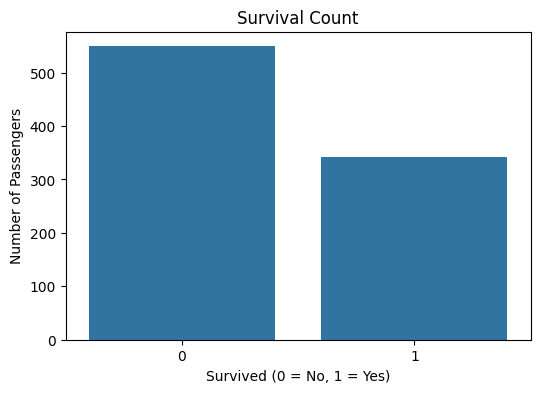

In [60]:
## 8. Visualization (EDA)
## 8.1 Survival Count Visualization
plt.figure(figsize=(6,4))

sns.countplot(
    x="Survived",
    data=df
)

plt.title("Survival Count")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")

plt.show()

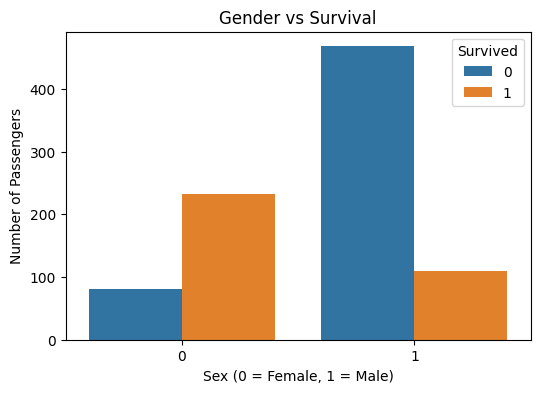

In [61]:
## 8.2 Gender vs Survival Graph
plt.figure(figsize=(6,4))

sns.countplot(
    x="Sex",
    hue="Survived",
    data=df
)

plt.title("Gender vs Survival")
plt.xlabel("Sex (0 = Female, 1 = Male)")
plt.ylabel("Number of Passengers")

plt.show()

In [62]:
X = df.drop("Survived", axis=1)
y = df["Survived"]

In [63]:
X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,1,22.0,1,0,7.2500,2
1,1,0,38.0,1,0,71.2833,0
2,3,0,26.0,0,0,7.9250,2
3,1,0,35.0,1,0,53.1000,2
4,3,1,35.0,0,0,8.0500,2


In [64]:
y.head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

In [65]:
## 9. Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [66]:
X_train.shape

(712, 7)

In [67]:
X_test.shape

(179, 7)

In [68]:
## 10. Train Logistic Regression Model
model = LogisticRegression(max_iter=1000)

model.fit(
    X_train,
    y_train
)

LogisticRegression(max_iter=1000)

In [69]:
## 11. Make Predictions
y_pred = model.predict(X_test)

In [70]:
## 12. Accuracy Score
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 0.8100558659217877


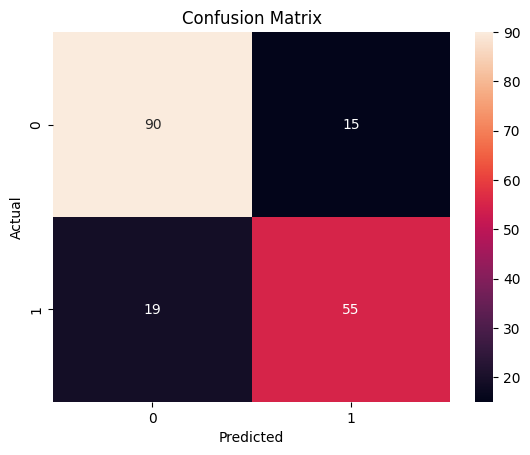

In [71]:
## 13. Confusion Matrix
cm = confusion_matrix(
    y_test,
    y_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [72]:
## 14. Classification Report
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



In [73]:
## 15. Random Forest Model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

RandomForestClassifier(random_state=42)

In [74]:
## 16. Prediction
rf_pred = rf_model.predict(X_test)

In [75]:
## 17. Accuracy
rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.8100558659217877


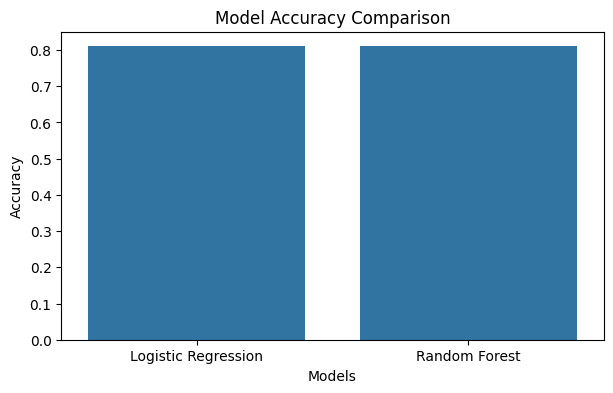

In [76]:
## 18. Model Comparison
models = ["Logistic Regression", "Random Forest"]

accuracy_values = [
    accuracy,
    rf_accuracy
]

plt.figure(figsize=(7,4))

sns.barplot(
    x=models,
    y=accuracy_values
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.show()

In [ ]:
## Conclusion

##In this project, a machine learning model was built to predict Titanic passenger survival using classification techniques.
##After data preprocessing and model training, the Random Forest model achieved good accuracy (~0.81), showing effective performance on the dataset.
##This project helped in understanding the complete ML workflow from data handling to model evaluation.